In [3]:
##Explorative Analyse der Großkorpora, um einen ausgewogenes Sample für die Analyse zu finden

In [35]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import pyphen
import spacy
import seaborn as sns

In [28]:
nlp = spacy.load("de_core_news_sm")

In [4]:
def read_txt_file(file_path):
    """
    Read a single txt file and return its content as a string.

    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

In [ ]:
## Einlesen von Kafkas juristischen Texten
kafka_jur = []
kafka_jur_dir = 'data/kafka_jur'
for filename in os.listdir(kafka_jur_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_jur_dir, filename)
        text = read_txt_file(file_path)
        kafka_jur.append(text)

kafka_jur_df = pd.DataFrame({'text': kafka_jur})
kafka_jur_df.reset_index(inplace=True)
kafka_jur_df.rename(columns={'index': 'id'}, inplace=True)

kafka_jur_df["text"] = (
    kafka_jur_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_jur_df["corpus"] = "kafka_jur"

kafka_jur_df

,id,text,word_count,corpus
0,0,Umfang der Versicherungspflicht der Baugewerbe...,8895,kafka_jur
1,1,8. „Die Mutterschaftsversicherung vom Standpun...,255,kafka_jur
2,2,"Kriegslage, Gefahrenklassen-Einreihung und Unf...",4764,kafka_jur
3,3,Unfallverhütung und erste Hilfe A. Die Unfallv...,4801,kafka_jur
4,4,Rede zur Amtseinsetzung des Direktors Diese Wa...,621,kafka_jur
5,5,Löblicher Vorstand! Der ergebenst Gefertigte e...,179,kafka_jur
6,6,Die Arbeiter-Versicherung und die Unternehmer ...,3239,kafka_jur


In [ ]:
## Einlesen von Kafkas Briefen an Felice Bauer
kafka_bauer = []
kafka_bauer_dir = 'data/kafka_briefe/Felice-Bauer'
for filename in os.listdir(kafka_bauer_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_bauer_dir, filename)
        text = read_txt_file(file_path)
        kafka_bauer.append(text)

kafka_bauer_df = pd.DataFrame({'text': kafka_bauer})
kafka_bauer_df.reset_index(inplace=True)
kafka_bauer_df.rename(columns={'index': 'id'}, inplace=True)

kafka_bauer_df["text"] = (
    kafka_bauer_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_bauer_df["corpus"] = "kafka_bauer"

kafka_bauer_df

,id,text,word_count,corpus
0,0,"Meine liebste Felice! Wie? Kopfschmerzen, schl...",446,kafka_bauer
1,1,Liebste Felice! Erst in dem letzten Brief erke...,589,kafka_bauer
2,2,"Der dritte Brief, den ich heute anfange. Immer...",290,kafka_bauer
3,3,Im Augenblick schlägt mir das Herz mit der Wut...,509,kafka_bauer
4,4,"Eben, Liebste, habe ich mir den Kopf zermarter...",599,kafka_bauer
...,...,...,...,...
311,311,Ich habe heute aus verschiedenen Gründen statt...,1711,kafka_bauer
312,312,"Mein liebstes Kind, in meinem Roman gehn eben ...",1011,kafka_bauer
313,313,"Das Wetter ist hier auch sehr schön, man nützt...",524,kafka_bauer
314,314,"Um die Wahrheit zu sagen, F.: in dem gestrigen...",556,kafka_bauer


In [ ]:
## Einlesen von Kafkas Briefen an Maxc Brod
kafka_brod = []
kafka_brod_dir = 'data/kafka_briefe/Max-Brod'
for filename in os.listdir(kafka_brod_dir):
    if filename.endswith('.txt'):
        file_path = os.path.join(kafka_brod_dir, filename)
        text = read_txt_file(file_path)
        kafka_brod.append(text)

kafka_brod_df = pd.DataFrame({'text': kafka_brod})
kafka_brod_df.reset_index(inplace=True)
kafka_brod_df.rename(columns={'index': 'id'}, inplace=True)

kafka_brod_df["text"] = (
    kafka_brod_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

kafka_brod_df["corpus"] = "kafka_brod"

kafka_brod_df

,id,text,word_count,corpus
0,0,"Lieber Max, Ich danke dir. Sicher verzeihst Du...",128,kafka_brod
1,1,"Mein lieber Max Ich bin doch ganz unbrauchbar,...",203,kafka_brod
2,2,"Guten Morgen! Lieber Max, ich stand gestern be...",108,kafka_brod
3,3,Mein liebster Max! Nach langer Plage höre ich ...,203,kafka_brod
4,4,"12/2 1907 Lieber Max, ich schreibe Dir gerne, ...",366,kafka_brod
...,...,...,...,...
113,113,"Mein lieber Max, wer verlangt denn, dass Du mi...",349,kafka_brod
114,114,"Lieber Max, zur sofortigen Richtigstellung, ic...",63,kafka_brod
115,115,"Liebster Max, nicht weil es an und für sich un...",227,kafka_brod
116,116,"[den] 10. Juli [191] 1 Mein liebster Max, weil...",462,kafka_brod


In [41]:
## Einlesen von Kafkas literarischen Texten
kafka_lit = []
kafka_lit_genre = []
kafka_lit_dir = 'data/kafka_korpus'
for root, dirs, files in os.walk(kafka_lit_dir):
    for filename in files:
        if filename.endswith(".txt"):
            file_path = os.path.join(root, filename)
            text = read_txt_file(file_path)

            kafka_lit.append(text)

            genre = os.path.basename(root)
            kafka_lit_genre.append(genre)

kafka_lit_df = pd.DataFrame({'text': kafka_lit, 'genre': kafka_lit_genre})
kafka_lit_df.reset_index(inplace=True)
kafka_lit_df.rename(columns={'index': 'id'}, inplace=True)

kafka_lit_df["text"] = (
    kafka_lit_df["text"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
kafka_lit_df["doc"] = kafka_lit_df["text"].apply(nlp)
kafka_lit_df["tokens"] = kafka_lit_df["doc"].apply(lambda doc: [token.text for token in doc])
kafka_lit_df["token_count"] = kafka_lit_df["tokens"].apply(len)
kafka_lit_df["corpus"] = "kafka_lit"

kafka_lit_df

,id,text,genre,doc,tokens,token_count,corpus
0,0,Ich war in großer Verlegenheit: eine dringende...,erzählungen,"(Ich, war, in, großer, Verlegenheit, :, eine, ...","[Ich, war, in, großer, Verlegenheit, :, eine, ...",2608,kafka_lit
1,1,"I Als Eduard Raban, durch den Flurgang kommend...",erzählungen,"(I, Als, Eduard, Raban, ,, durch, den, Flurgan...","[I, Als, Eduard, Raban, ,, durch, den, Flurgan...",9958,kafka_lit
2,2,"Ein Philosoph trieb sich immer dort herum, wo ...",erzählungen,"(Ein, Philosoph, trieb, sich, immer, dort, her...","[Ein, Philosoph, trieb, sich, immer, dort, her...",244,kafka_lit
3,3,Gegen zwölf Uhr standen schon einige Leute auf...,erzählungen,"(Gegen, zwölf, Uhr, standen, schon, einige, Le...","[Gegen, zwölf, Uhr, standen, schon, einige, Le...",16905,kafka_lit
4,4,Wie sich mein Leben verändert hat und wie es s...,erzählungen,"(Wie, sich, mein, Leben, verändert, hat, und, ...","[Wie, sich, mein, Leben, verändert, hat, und, ...",16065,kafka_lit
...,...,...,...,...,...,...,...
59,59,"Es war ein Geier, der hackte in meine Füße. St...",erzählungen,"(Es, war, ein, Geier, ,, der, hackte, in, mein...","[Es, war, ein, Geier, ,, der, hackte, in, mein...",325,kafka_lit
60,60,"Kleines Arbeitszimmer, hohes Fenster, davor ei...",dramen,"(Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...","[Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...",5052,kafka_lit
61,61,"Jemand mußte Josef K. verleumdet haben, denn o...",roman_fragmente,"(Jemand, mußte, Josef, K., verleumdet, haben, ...","[Jemand, mußte, Josef, K., verleumdet, haben, ...",89897,kafka_lit
62,62,"Als der sechzehnjährige Karl Roßmann, der von ...",roman_fragmente,"(Als, der, sechzehnjährige, Karl, Roßmann, ,, ...","[Als, der, sechzehnjährige, Karl, Roßmann, ,, ...",100006,kafka_lit


In [ ]:
kafka_lit_df.groupby("genre")["token_count"].agg([
    "count",
    "sum",
    "mean",
    "median",
    "min",
    "max"å
])

,count,sum,mean,median,min,max
genre,,,,,,
dramen,1,5052,5052.000000,5052.0,5052,5052
erzählungen,60,180736,3012.266667,806.0,75,22297
roman_fragmente,3,282716,94238.666667,92813.0,89897,100006


In [ ]:
kafka_korpus_df = pd.concat([kafka_jur_df, kafka_bauer_df, kafka_brod_df, kafka_lit_df], ignore_index=True)
kafka_korpus_df = kafka_korpus_df[kafka_korpus_df.token_count != 0]
kafka_korpus_df["doc"] = kafka_korpus_df["text"].apply(nlp)
kafka_korpus_df["tokens"] = kafka_korpus_df["doc"].apply(lambda doc: [token.text for token in doc])
kafka_korpus_df["token_count"] = kafka_korpus_df["tokens"].apply(len)

kafka_korpus_df

,id,text,word_count,corpus,genre,doc,tokens,token_count
0,0,Umfang der Versicherungspflicht der Baugewerbe...,8895,kafka_jur,NaN,"(Umfang, der, Versicherungspflicht, der, Bauge...","[Umfang, der, Versicherungspflicht, der, Bauge...",10061
1,1,8. „Die Mutterschaftsversicherung vom Standpun...,255,kafka_jur,NaN,"(8., „, Die, Mutterschaftsversicherung, vom, S...","[8., „, Die, Mutterschaftsversicherung, vom, S...",287
2,2,"Kriegslage, Gefahrenklassen-Einreihung und Unf...",4764,kafka_jur,NaN,"(Kriegslage, ,, Gefahrenklassen-Einreihung, un...","[Kriegslage, ,, Gefahrenklassen-Einreihung, un...",5352
3,3,Unfallverhütung und erste Hilfe A. Die Unfallv...,4801,kafka_jur,NaN,"(Unfallverhütung, und, erste, Hilfe, A., Die, ...","[Unfallverhütung, und, erste, Hilfe, A., Die, ...",5247
4,4,Rede zur Amtseinsetzung des Direktors Diese Wa...,621,kafka_jur,NaN,"(Rede, zur, Amtseinsetzung, des, Direktors, Di...","[Rede, zur, Amtseinsetzung, des, Direktors, Di...",702
...,...,...,...,...,...,...,...,...
500,59,"Es war ein Geier, der hackte in meine Füße. St...",256,kafka_lit,erzählungen,"(Es, war, ein, Geier, ,, der, hackte, in, mein...","[Es, war, ein, Geier, ,, der, hackte, in, mein...",325
501,60,"Kleines Arbeitszimmer, hohes Fenster, davor ei...",4036,kafka_lit,dramen,"(Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...","[Kleines, Arbeitszimmer, ,, hohes, Fenster, ,,...",5052
502,61,"Jemand mußte Josef K. verleumdet haben, denn o...",74310,kafka_lit,roman_fragmente,"(Jemand, mußte, Josef, K., verleumdet, haben, ...","[Jemand, mußte, Josef, K., verleumdet, haben, ...",89897
503,62,"Als der sechzehnjährige Karl Roßmann, der von ...",83950,kafka_lit,roman_fragmente,"(Als, der, sechzehnjährige, Karl, Roßmann, ,, ...","[Als, der, sechzehnjährige, Karl, Roßmann, ,, ...",100006


In [33]:
kafka_korpus_df.groupby("corpus")["token_count"].agg([
    "count",
    "sum",
    "mean",
    "median",
    "min",
    "max"
])

,count,sum,mean,median,min,max
corpus,,,,,,
kafka_bauer,316,161237,510.243671,474.5,0,3354
kafka_brod,118,76655,649.618644,431.5,59,3180
kafka_jur,7,25432,3633.142857,3582.0,201,10061
kafka_lit,64,468504,7320.375000,956.0,75,100006


In [34]:
kafka_korpus_df.groupby("corpus")["token_count"].describe()

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
kafka_bauer,316.0,510.243671,438.464841,0.0,232.25,474.5,621.25,3354.0
kafka_brod,118.0,649.618644,563.733023,59.0,222.00,431.5,918.50,3180.0
kafka_jur,7.0,3633.142857,3615.864186,201.0,494.50,3582.0,5299.50,10061.0
kafka_lit,64.0,7320.375000,20008.305012,75.0,351.00,956.0,4181.75,100006.0


<Axes: xlabel='corpus', ylabel='token_count'>

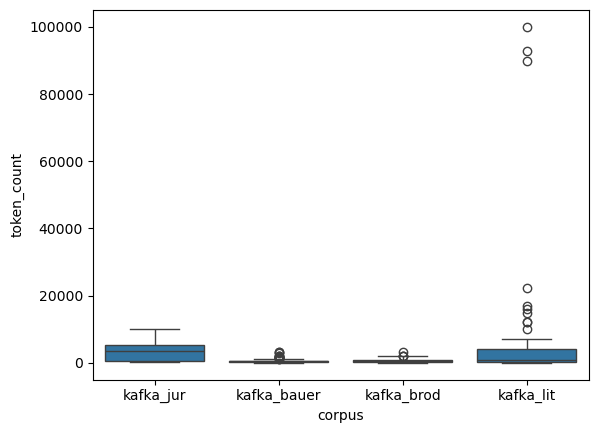

In [36]:
sns.boxplot(data=kafka_korpus_df, x="corpus", y="token_count")